In [2]:
import fmatoolbox as fma
from math import *
import matplotlib.pyplot as plt
import numpy as np
import regions as rg
from scipy import signal
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import hamming, pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.manifold import TSNE

%load_ext autoreload
%autoreload 2

In [3]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
R = rg.data.Regions(session,states=['sws','rem'],events=['ripples'])

Patterns

In [4]:
fr = R.unitFiringRate(regs=["nr"], states = "sws", window = 0.02)

In [33]:
fr = np.array([[0,0,1,0,0],[1,0,0,1,0],[2,0,1,1,0],[3,0,1,0,0],[4,0,0,0,0],[5,0,0,0,0],[6,0,0,0,1],[7,0,0,1,0],[8,0,1,0,0],[9,0,0,0,0]])

In [5]:
patterns = [] 
nn = len(fr[0])
nt = len(fr)
interval_width = 4

# somme de l'activité sur tous les neurones à chaque timestep
activity = fr[:, 1:].sum(axis=1)  # shape (nt,), on ignore la colonne temps

# booléen : actif ou non à chaque timestep
active = activity > 0

# transitions
starts = np.where(~active[:-1] & active[1:])[0] + 1   # 0 -> actif
stops  = np.where(active[:-1] & ~active[1:])[0]        # actif -> 0

# cas où la première frame est active
if active[0]:
    starts = np.concatenate([[0], starts])

# cas où la dernière frame est active
if active[-1]:
    stops = np.concatenate([stops, [nt-1]])

intervals = np.column_stack([starts, stops])
intervals = intervals[intervals[:,1] - intervals[:,0] > interval_width] 

In [16]:
print(len(intervals))
print(intervals[:5])
print(intervals[:5]*0.02)
size, intervals2, size_t, profiles = R.avalanches(regs=["nr"],states="sws",thresh=0,window=0.02,step=1,smooth=False, profile=True)
intervals2 = intervals2["nr"]  
print(len(intervals2))
print(intervals2[:5])
intervals2 = intervals2[intervals2[:,1] - intervals2[:,0] > (interval_width+1)*0.02] 
print(len(intervals2))
print(intervals2[:5])

7780
[[  0  22]
 [ 24  81]
 [ 83 108]
 [111 234]
 [236 289]]
[[0.   0.44]
 [0.48 1.62]
 [1.66 2.16]
 [2.22 4.68]
 [4.72 5.78]]
37879
[[243.6  244.06]
 [244.08 245.24]
 [245.26 245.78]
 [245.82 248.3 ]
 [248.32 249.4 ]]
8450
[[243.6  244.06]
 [244.08 245.24]
 [245.26 245.78]
 [245.82 248.3 ]
 [248.32 249.4 ]]


In [6]:
patterns = [(fr[start:stop+1, 1:].sum(axis=0)>0).astype(int) for start, stop in intervals]

# dédupliquer les patterns
patterns_array = np.array(patterns)
unique_patterns, counts = np.unique(patterns_array, axis=0, return_counts=True)
print(f"Patterns totaux : {len(patterns)}")
print(f"Patterns uniques : {len(unique_patterns)}")
patterns = unique_patterns

Patterns totaux : 7780
Patterns uniques : 7756


Distribution

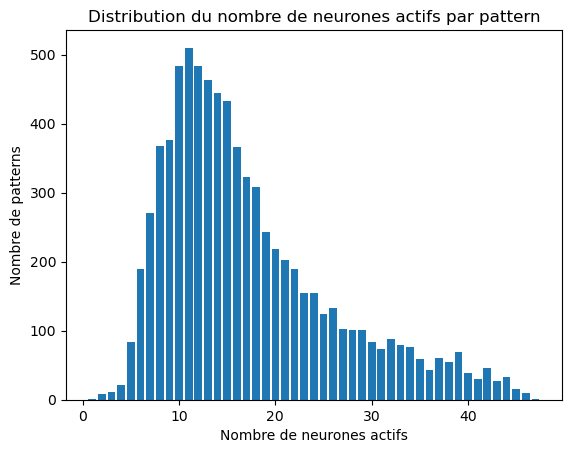

In [7]:
dp = {}
for i in range(len(patterns)):
    n = np.sum(patterns[i])
    if n not in dp:
        dp[n] = 0
    dp[n]+=1
l1,l2=[],[]
for i in dp:
    l1.append(i)
    l2.append(dp[i])

plt.bar(l1,l2)
plt.xlabel('Nombre de neurones actifs')
plt.ylabel('Nombre de patterns')
plt.title('Distribution du nombre de neurones actifs par pattern')
plt.show()

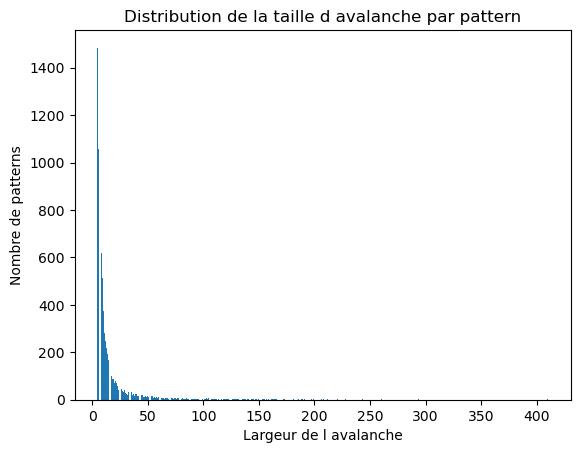

In [20]:
dp = {}
for i in range(len(intervals)):
    n = intervals[i,1] - intervals[i,0]   
    if n not in dp:
        dp[n] = 0
    dp[n]+=1
l1,l2=[],[]
for i in dp:
    l1.append(i)
    l2.append(dp[i])

plt.bar(l1,l2)
plt.xlabel('Largeur de l avalanche')
plt.ylabel('Nombre de patterns')
plt.title('Distribution de la taille d avalanche par pattern')
plt.show()

Fonctions de clustering

In [8]:
def clustKMeans(patterns, n_clusters=2):
    
    # 1. construire la matrice de patterns
    X = np.array(patterns)  # shape (n_avalanches, n_neurons)

    # 2. normalisation : pas de normalisation pertinente ici
    #scaler = StandardScaler()
    #X_scaled = scaler.fit_transform(X)
    X_scaled = X

    # 3. clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    return X_scaled, labels

def redPCA(X_scaled, labels, n_clusters=2):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_scaled)

    # 5. plot
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    for k in range(n_clusters):
        mask = labels == k
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
               color=colors[k], label=f'Cluster {k}', alpha=0.6, s=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA + KMeans des patterns d\'avalanches')
    ax.legend()
    plt.show()

In [9]:
def Hamming_tSNE(patterns, n_clusters=2, method='average'):#ward meilleur que 'average' 
    X = np.array(patterns)  # shape (n_avalanches, n_neurons)

    # --- 1. Matrice de distances de Hamming ---
    # pdist calcule toutes les paires de distances
    hamming_distances = pdist(X, metric='hamming')
    hamming_matrix = squareform(hamming_distances)  # shape (n_avalanches, n_avalanches)

    # --- 2. Clustering hiérarchique sur Hamming ---
    # 'ward' minimise la variance intra-cluster à chaque fusion
    # autres options : 'average', 'complete', 'single'
    linkage_matrix = linkage(hamming_distances, method=method)
    labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    return X, labels, linkage_matrix

def tSNE(X, labels, linkage_matrix, n_clusters=2):

    # optionnel : visualiser le dendrogramme pour choisir n_clusters
    from scipy.cluster.hierarchy import dendrogram
    fig_dend, ax_dend = plt.subplots(figsize=(12, 4))
    dendrogram(linkage_matrix, ax=ax_dend, truncate_mode='lastp', p=20)
    ax_dend.set_title('Dendrogramme (Hamming)')
    ax_dend.set_xlabel('Avalanches')
    ax_dend.set_ylabel('Distance de Hamming')
    plt.show()

    # --- 3. Réduction de dimension t-SNE ---
    tsne = TSNE(
        n_components=2,
        metric='hamming',      # t-SNE utilise directement Hamming
        perplexity=min(50, len(X)//4),  # règle empirique : ~n_samples/4
        random_state=42,
        max_iter=1000
    )
    X_2d = tsne.fit_transform(X)

    # --- 4. Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    for k in range(1, n_clusters + 1):  # fcluster commence à 1
        mask = labels == k
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                color=colors[k-1], label=f'Cluster {k}',
                alpha=0.6, s=20)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title('Clustering Hamming + t-SNE')
    ax.legend()
    plt.show()

Tests avec patterns simples

In [10]:
patterns = []

# 10 patterns : plus de 1 dans les 20 premiers, plus de 0 dans les 27 derniers
for _ in range(10):
    first = np.random.choice([0, 1], size=20, p=[0.2, 0.8])  # 70% de 1
    last  = np.random.choice([0, 1], size=27, p=[0.8, 0.2])  # 30% de 1
    patterns.append(np.concatenate([first, last]))

# 10 patterns : plus de 0 dans les 20 premiers, plus de 1 dans les 27 derniers
for _ in range(10):
    first = np.random.choice([0, 1], size=20, p=[0.8, 0.2])  # 30% de 1
    last  = np.random.choice([0, 1], size=27, p=[0.2, 0.8])  # 70% de 1
    patterns.append(np.concatenate([first, last]))

patterns = np.array(patterns)  # shape (20, 47)

patterns[5], patterns[15]

(array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0]),
 array([0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
        1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1]))

[[1 1 1 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1]
 [1 1 1 1 1 0 0 0 1 1 0 0 0 1 1 0 0 0 0 1]
 [1 1 0 1 1 1 1 1 0 1 0 1 1 0 0 0 1 0 0 0]
 [1 1 1 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 1 1 0]
 [1 1 1 1 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0]
 [1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 0 1 0 0]
 [1 1 1 0 0 1 1 1 1 1 0 0 0 0 1 1 0 1 1 0]
 [1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 1 0 0 0]
 [0 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0 1]
 [1 0 0 1 1 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1]
 [0 1 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0]
 [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1]
 [1 1 1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0]
 [1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0]
 [1 1 1 0 1 1 1 1 0 0 1 0 1 0 0 0 1 0 1 0]
 [1 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 0]
 [1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 1 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 1]
 [0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1 1]
 [0 1 0 0 1 0 0 0 0 1 1 0 0 1 1 1 1 0 1 1]
 [1 0 0 0 0

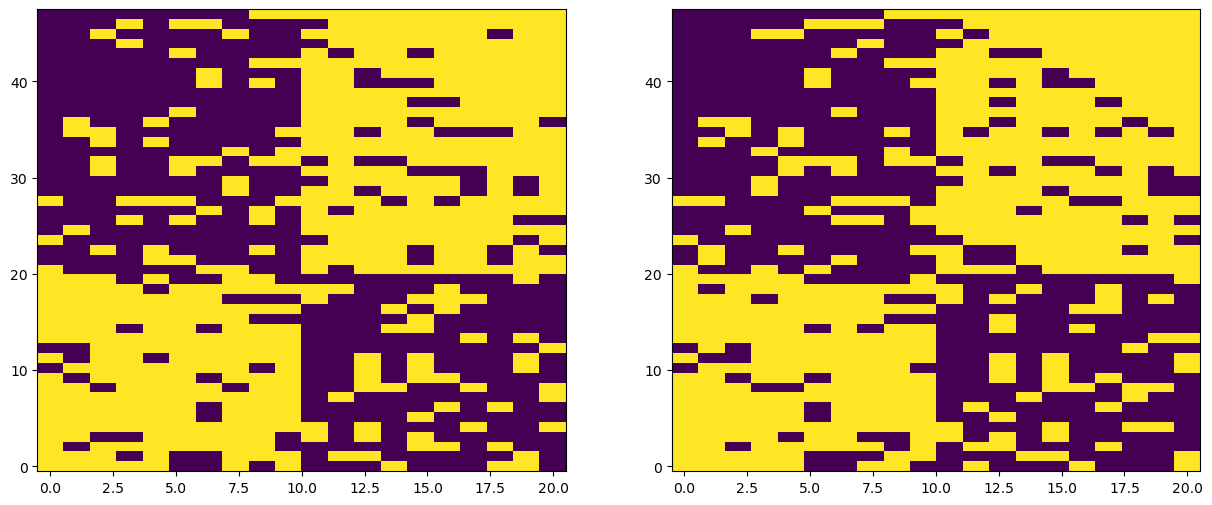

In [11]:
M = np.transpose(patterns)

fig, axs = plt.subplots(1,2, figsize=(15, 6))
ax1,ax2 = axs.flatten()

fma.plotting.plotColorMap(M, ax=ax1)

indices = np.lexsort(M)

M=M[:, indices]

print(M)

fma.plotting.plotColorMap(M, ax=ax2)

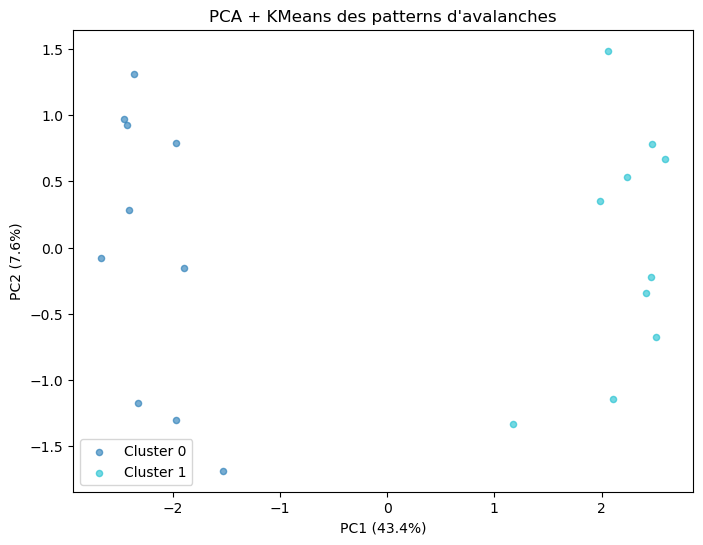

In [12]:
X_scaled, labels = clustKMeans(patterns, n_clusters=2)
redPCA(X_scaled, labels)

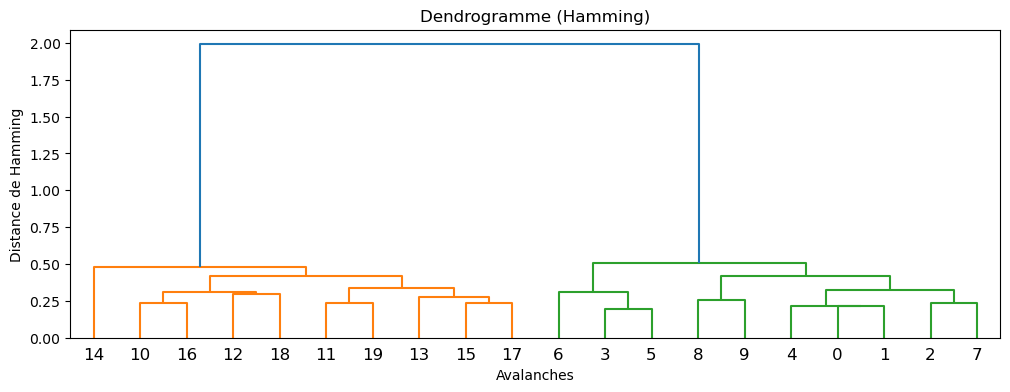

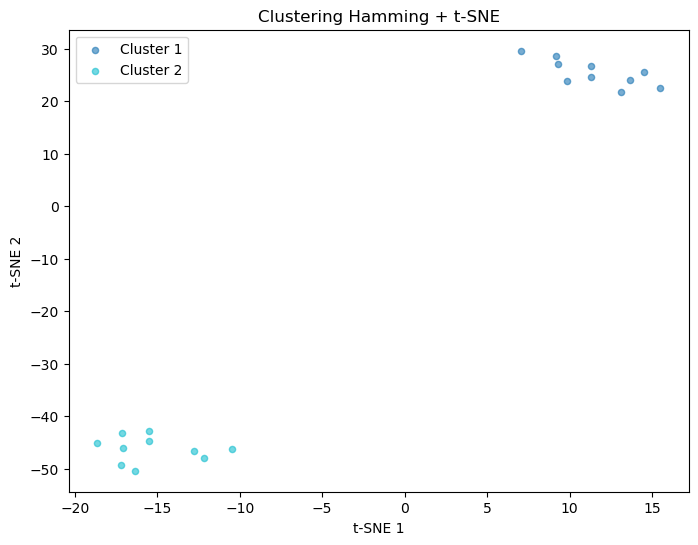

In [13]:
X, labels, linkage_matrix = Hamming_tSNE(patterns, n_clusters=2, method='ward')
tSNE(X, labels, linkage_matrix)

Avec les patterns d'une vrai session

In [14]:
patterns = [(fr[start:stop+1, 1:].sum(axis=0)>0).astype(int) for start, stop in intervals]
patterns_array = np.array(patterns)
unique_patterns, counts = np.unique(patterns_array, axis=0, return_counts=True)
print(len(patterns_array), len(unique_patterns))
patterns = unique_patterns

7780 7756


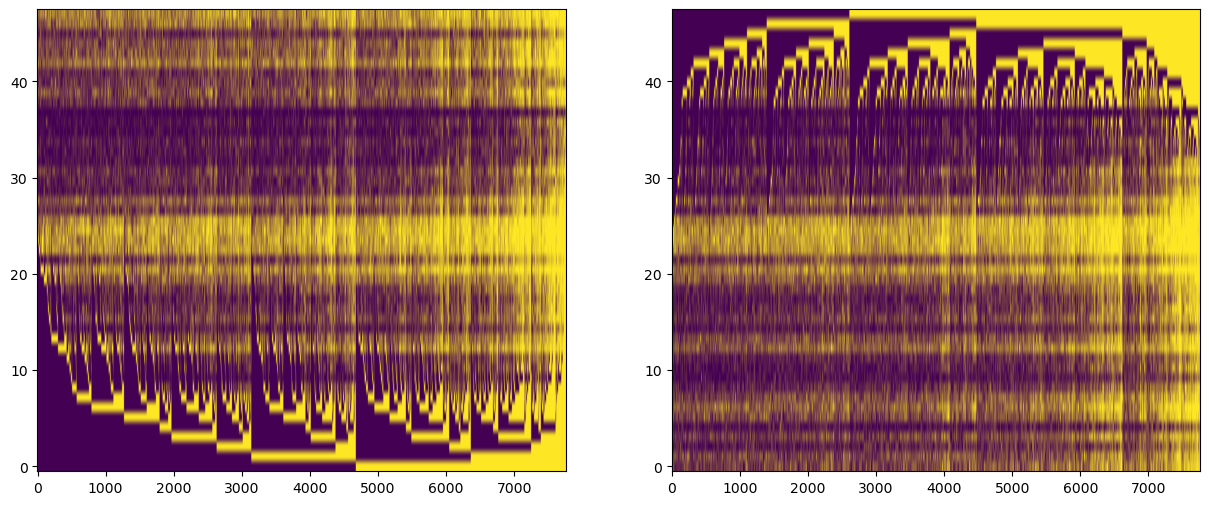

In [16]:
M = np.transpose(patterns)

fig, axs = plt.subplots(1,2, figsize=(15, 6))
ax1,ax2 = axs.flatten()

fma.plotting.plotColorMap(M, ax=ax1)

indices = np.lexsort(M)

M=M[:, indices]

fma.plotting.plotColorMap(M, ax=ax2)


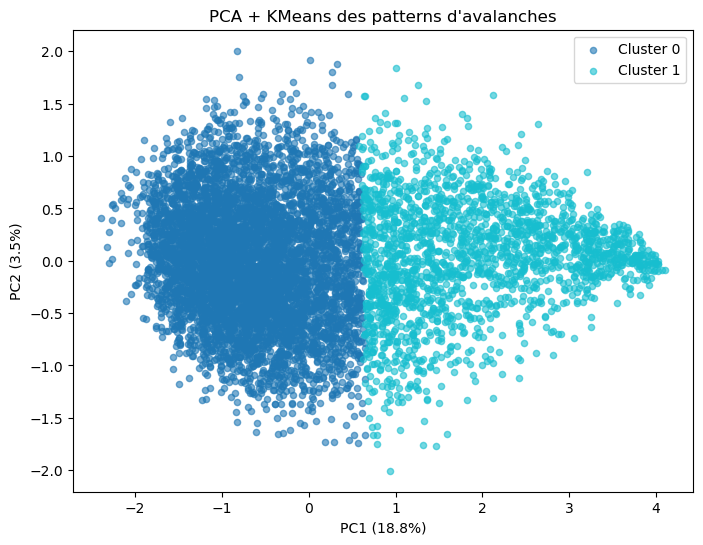

In [17]:
X_scaled, labels = clustKMeans(patterns, n_clusters=2)
redPCA(X_scaled, labels, n_clusters=2)

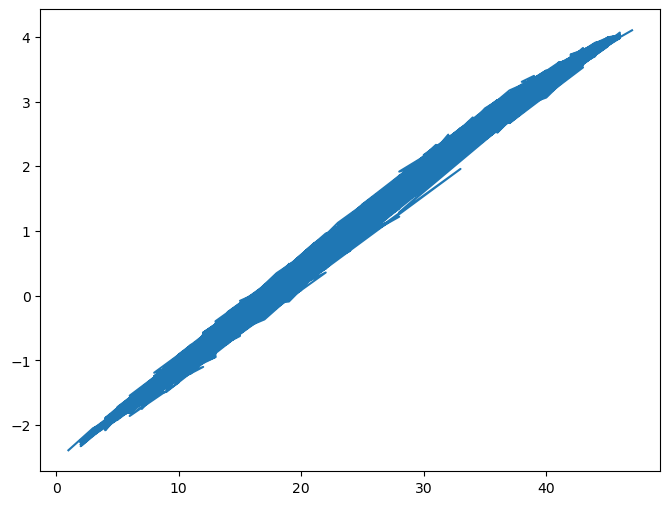

In [18]:
#PC1 selon nombre neurones actifs
labels
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

    # 5. plot
fig, ax = plt.subplots(figsize=(8, 6))
nn=patterns.sum(axis=1)
plt.plot(nn,X_2d[:, 0])
plt.show()

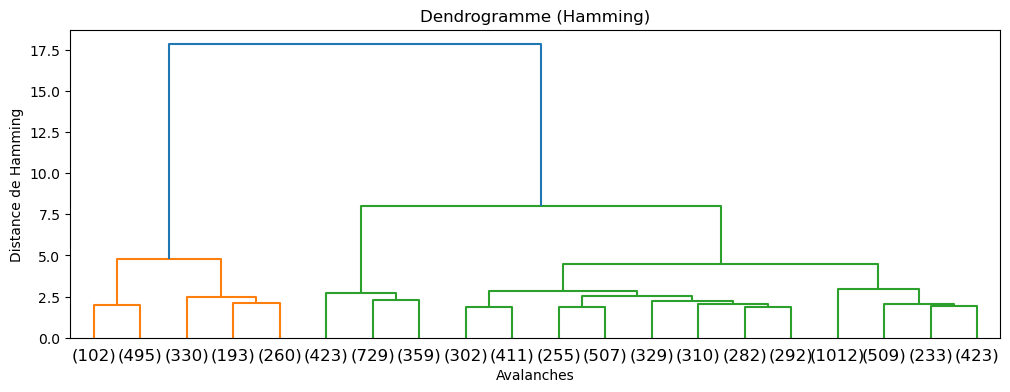

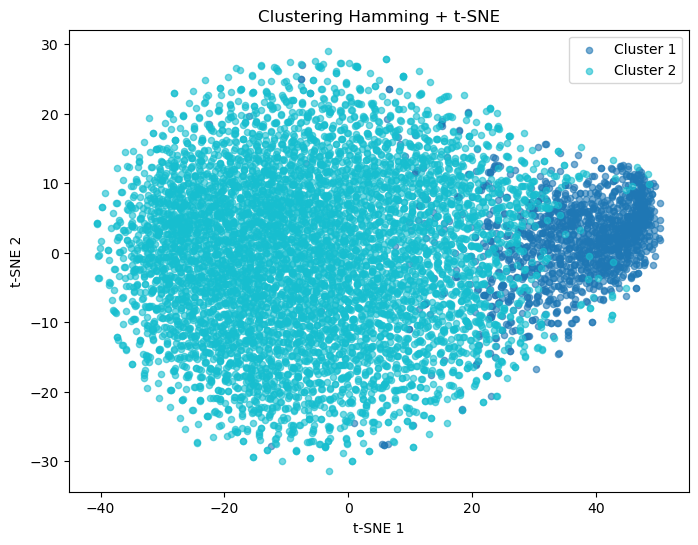

In [19]:
X, labels, linkage_matrix = Hamming_tSNE(patterns, n_clusters=2, method='ward')
tSNE(X, labels, linkage_matrix)

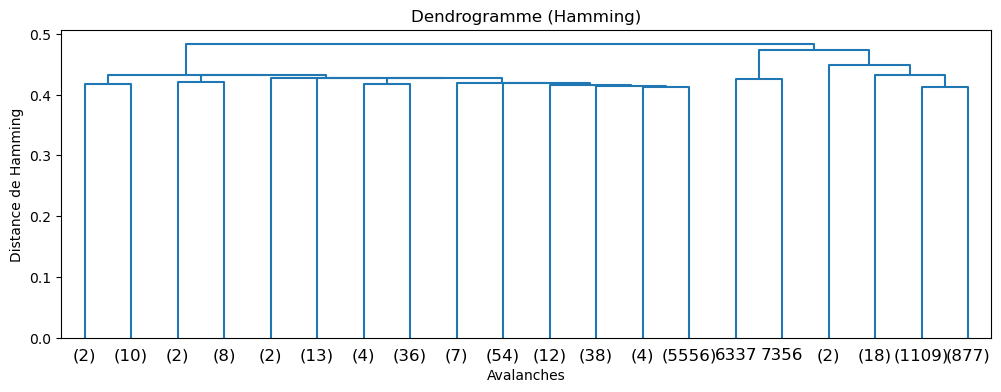

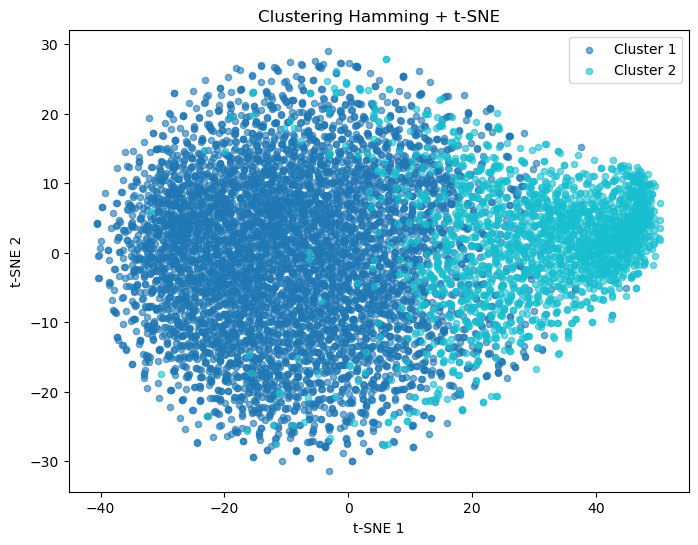

In [23]:
X, labels, linkage_matrix = Hamming_tSNE(patterns, n_clusters=2, method='average')
tSNE(X, labels, linkage_matrix)

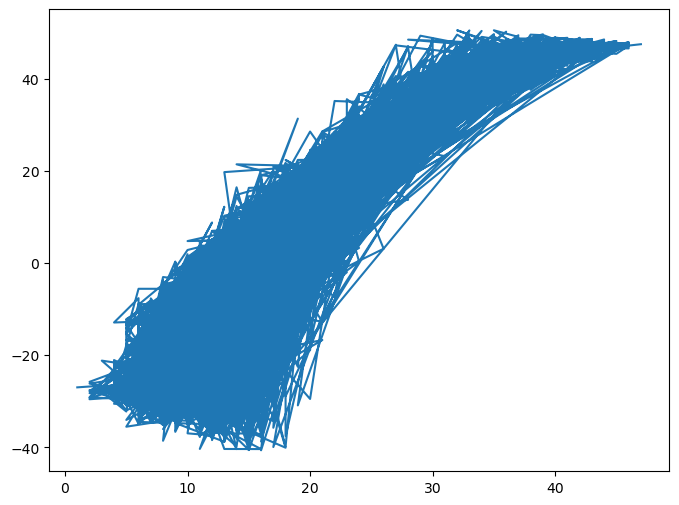

In [24]:
tsne = TSNE(
        n_components=2,
        metric='hamming',      # t-SNE utilise directement Hamming
        perplexity=min(50, len(X)//4),  # règle empirique : ~n_samples/4
        random_state=42,
        max_iter=1000
    )
X_2d = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
nn=patterns.sum(axis=1)
plt.plot(nn,X_2d[:, 0])
plt.show()

Exploration des clusters

In [21]:
clust1 = patterns[labels == 1] 
clust2 = patterns[labels == 2]
len(clust1), len(clust2)

(1380, 6376)

In [22]:
nt = 25

counts1 = clust1.sum(axis=1)       # nombre de 1 par pattern
mean1   = counts1.mean()
std1    = counts1.std()
sup1=len(counts1[counts1>nt])
p1 = sup1/len(counts1)

counts2 = clust2.sum(axis=1)       # nombre de 1 par pattern
mean2   = counts2.mean()
std2    = counts2.std()
sup2=len(counts2[counts2>nt])
p2=sup2/len(counts2)

print(counts1)
print(counts2)

print(mean1, std1, mean2, std2)
print(sup1,p1,sup2,p2)

print("Dans le 1er cluster, il y a en moyenne ", mean1, "neurones actifs, avec un écart-type de ", std1,". On remarque également qu'un pourcentage de ",p1," des patterns contient au moins ", nt, " neurones actifs.")

print("Dans le 2ème cluster, il y a en moyenne ", mean2, "neurones actifs, avec un écart-type de ", std2,". On remarque également qu'un pourcentage de ",p2," des patterns contient au moins ", nt, " neurones actifs.")



[18 28 24 ... 46 46 47]
[ 1  3  5 ... 24 24 31]
32.15942028985507 6.500107442603193 13.988080301129235 5.25693504585726
1162 0.8420289855072464 166 0.026035131744040152
Dans le 1er cluster, il y a en moyenne  32.15942028985507 neurones actifs, avec un écart-type de  6.500107442603193 . On remarque également qu'un pourcentage de  0.8420289855072464  des patterns contient au moins  25  neurones actifs.
Dans le 2ème cluster, il y a en moyenne  13.988080301129235 neurones actifs, avec un écart-type de  5.25693504585726 . On remarque également qu'un pourcentage de  0.026035131744040152  des patterns contient au moins  25  neurones actifs.
